In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

from sklearn.datasets import make_moons
from sklearn.datasets import make_circles

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)

n_samples = 1000
n_noise = 28  # столько шумовых признаков

# --- Сигнальные признаки (2 шт.) ---
# impact_strength_m40: нормальная, строгое перекрытие, но есть различие
# класс A: mean=65, std=10
# класс B: mean=55, std=10
# разница = 10, std = 10 → overlap = 1.0

sig1_A = np.random.normal(65, 10, n_samples // 2)
sig1_B = np.random.normal(55, 10, n_samples // 2)

# yield_ratio: тоже слабый сигнал
# класс A: mean=0.75, std=0.06
# класс B: mean=0.70, std=0.06
# разница = 0.05, std = 0.06 → overlap = 0.83

sig2_A = np.random.normal(0.75, 0.06, n_samples // 2)
sig2_B = np.random.normal(0.70, 0.06, n_samples // 2)

# --- Таргет ---
y = np.concatenate([np.zeros(n_samples // 2), np.ones(n_samples // 2)])

# --- Шумовые признаки (28 шт.) ---
# Списки параметров (mean, std) для каждого шумового признака
noise_params = [
    (0.18, 0.02),   # carbon_pct
    (1.2, 0.4),     # manganese_pct
    (0.25, 0.08),   # silicon_pct
    (0.01, 0.004),  # sulfur_pct
    (0.012, 0.005), # phosphorus_pct
    (0.08, 0.06),   # chromium_pct
    (0.03, 0.02),   # nickel_pct
    (0.02, 0.01),   # copper_pct
    (0.04, 0.02),   # aluminum_pct
    (0.01, 0.005),  # vanadium_pct
    (0.02, 0.01),   # titanium_pct
    (0.03, 0.02),   # niobium_pct
    (0.006, 0.002), # nitrogen_pct
    (15.0, 5.0),    # uct_amplitude1
    (15.0, 5.0),    # uct_amplitude2
    (15.0, 5.0),    # uct_amplitude3
    (3.0, 1.5),     # uct_defect_depth1
    (3.0, 1.5),     # uct_defect_depth2
    (3.0, 1.5),     # uct_defect_depth3
    (12.0, 3.0),    # thickness_mm
    (2000.0, 300.0),# width_mm
    (12000.0, 2000.0), # length_mm
    (850.0, 30.0),  # temp_finish_rolling
    (580.0, 40.0),  # temp_coiling
    (25.0, 8.0),    # cooling_rate
    (25.0, 5.0),    # tension_rolling
    (6.0, 1.5),     # rolling_speed
    (22.0, 5.0),    # elongation_pct
]

noise_columns = [
    'carbon_pct', 'manganese_pct', 'silicon_pct', 'sulfur_pct', 
    'phosphorus_pct', 'chromium_pct', 'nickel_pct', 'copper_pct', 
    'aluminum_pct', 'vanadium_pct', 'titanium_pct', 'niobium_pct', 
    'nitrogen_pct', 'uct_amplitude1', 'uct_amplitude2', 'uct_amplitude3',
    'uct_defect_depth1', 'uct_defect_depth2', 'uct_defect_depth3',
    'thickness_mm', 'width_mm', 'length_mm', 'temp_finish_rolling',
    'temp_coiling', 'cooling_rate', 'tension_rolling', 'rolling_speed',
    'elongation_pct'
]

noise_data = {}
for i, (mean, std) in enumerate(noise_params):
    noise_data[noise_columns[i]] = np.random.normal(mean, std, n_samples)

# --- Собираем DataFrame ---
feature_names = ['impact_strength_m40', 'yield_ratio'] + noise_columns

df = pd.DataFrame(noise_data)
df['impact_strength_m40'] = np.concatenate([sig1_B, sig1_A])
df['yield_ratio'] = np.concatenate([sig2_B, sig2_A])
df['category'] = y

# Перемешаем строки
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# --- Анализ ---
X = df[feature_names]
y_true = df['category']

# Масштабирование (как в задаче)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

X_scaled = X

# Тестирование kNN
k_values = range(5, 250, 10)
results = []

for k in k_values:
    print(k)
    train_accs, test_accs = [], []
    for seed in range(30):
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y_true, test_size=0.3, random_state=seed
        )
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        train_accs.append(accuracy_score(y_train, knn.predict(X_train)))
        test_accs.append(accuracy_score(y_test, knn.predict(X_test)))
    results.append({'k': k, 'train_acc': np.mean(train_accs), 'test_acc': np.mean(test_accs)})

results_df = pd.DataFrame(results)
print("Вариант: Прокатный лист (2 сигнальных + 28 шумовых)")
print(f"k=5: test accuracy = {results_df.loc[results_df['k']==5, 'test_acc'].values[0]:.4f}")
best = results_df.loc[results_df['test_acc'].idxmax()]
print(f"Оптимальный k = {best['k']}: test accuracy = {best['test_acc']:.4f}")
k5 = results_df.loc[results_df['k']==5, 'test_acc'].values[0]
print(f"Прирост accuracy: {best['test_acc'] - k5:.4f}")

# Вывод первых строк DataFrame
print("\nПервые 5 строк:")
print(df.head())


5
15
25
35
45
55
65
75
85
95
105
115
125
135
145
155
165
175
185
195
205
215
225
235
245
Вариант: Прокатный лист (2 сигнальных + 28 шумовых)
k=5: test accuracy = 0.4888
Оптимальный k = 25.0: test accuracy = 0.5219
Прирост accuracy: 0.0331

Первые 5 строк:
   carbon_pct  manganese_pct  silicon_pct  sulfur_pct  phosphorus_pct  \
0    0.239705       0.202692     0.335947    0.007354        0.011625   
1    0.186847       1.136255     0.252721    0.015648        0.013660   
2    0.188297       0.914128     0.291510    0.011353        0.003447   
3    0.156488       1.055984     0.368557    0.009781        0.016166   
4    0.210759       1.038770     0.245114    0.007906        0.011508   

   chromium_pct  nickel_pct  copper_pct  aluminum_pct  vanadium_pct  ...  \
0     -0.015151    0.034040    0.039825      0.042912     -0.004543  ...   
1      0.111192    0.025215    0.015033      0.019995      0.019765  ...   
2      0.122565    0.014973    0.011858      0.059439      0.009908  ...   
3

k = 5
k = 15
k = 25
k = 35
k = 45
k = 55
k = 65
k = 75
k = 85
k = 95
k = 105
k = 115
k = 125
k = 135
k = 145
k = 155
k = 165
k = 175
k = 185
k = 195
k = 205
k = 215
k = 225
k = 235
k = 245


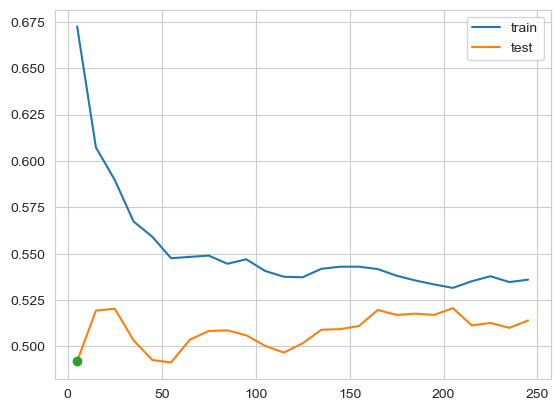

Последовательность скоров:
[0.492, 0.5193, 0.5203, 0.5033, 0.4927, 0.4913, 0.5037, 0.5083, 0.5087, 0.506, 0.5003, 0.4967, 0.5017, 0.509, 0.5093, 0.511, 0.5197, 0.517, 0.5177, 0.517, 0.5207, 0.5113, 0.5127, 0.51, 0.514]
Максимальный скор: 0.5207
При n_neighbors = 205
Прирост скора: 0.0287


In [7]:
X = df.drop(columns = ['category'])
y = df['category']

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(25*len(X)/100), 10):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.legend()
plt.show()

print('Последовательность скоров:')
print(list(np.array(Accuracy_test_list).round(4)))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4))
print('При n_neighbors =', np.argmax(np.array(Accuracy_test_list))*10 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

k = 5
k = 15
k = 25
k = 35
k = 45
k = 55
k = 65
k = 75
k = 85
k = 95
k = 105
k = 115
k = 125
k = 135
k = 145
k = 155
k = 165
k = 175
k = 185
k = 195
k = 205
k = 215
k = 225
k = 235
k = 245


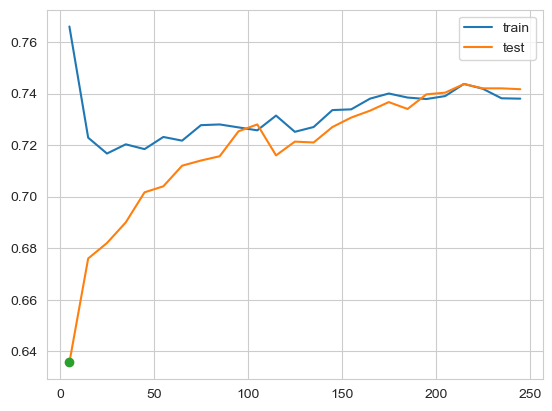

Последовательность скоров:
[0.6357, 0.676, 0.682, 0.69, 0.7017, 0.704, 0.712, 0.714, 0.7157, 0.7253, 0.728, 0.716, 0.7213, 0.721, 0.727, 0.7307, 0.7333, 0.7367, 0.734, 0.7397, 0.7403, 0.7437, 0.742, 0.742, 0.7417]
Максимальный скор: 0.7437
При n_neighbors = 215
Прирост скора: 0.108


In [8]:
X = df.drop(columns = ['category'])
y = df['category']

scaler = StandardScaler()
X = scaler.fit_transform(X)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(25*len(X)/100), 10):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.legend()
plt.show()

print('Последовательность скоров:')
print(list(np.array(Accuracy_test_list).round(4)))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4))
print('При n_neighbors =', np.argmax(np.array(Accuracy_test_list))*10 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))